# ISEL - CPS 
## Semestre 2023/24
# <br>
###  <center> Trabalho Prático 1 - Comunicações Digitais</center>
# </br>


Trabalho realizado por:
* Cristiano Sobral, número <b> 50272 </b>
* Rafael Dias, número <b> 50773 </b>
* Gustavo Santos, número <b> 50791 </b>

<b> Turma L31 - Joel Paulo </b>

# A. Quantificação

Considere que o conjunto de sinais em estudo foi adquirido com uma frequência de amostragem conhecida, $Fs$, e que a quantificação é realizada pela função em baixo.
Nesta função é criada a tabela com os valores de decisão e valores de quantificação e realuzada a quantificação uniforme (do tipo midrise).

Esta função tem como parâmetros de entrada o sinal a quantificar (x), o número de bits por amostra (R), o valor máximo a quantificar (Vmax). Como parâmetros de saída é devolvido o sinal quanfitifado (xq) e os indices associados ao nível de quantificação associado a cada amostra (iq). 

## A.1 Estudo do erro que quantificação
Use uma função sinusoidal e represente o sinal original, quantificado e o sinal de erro

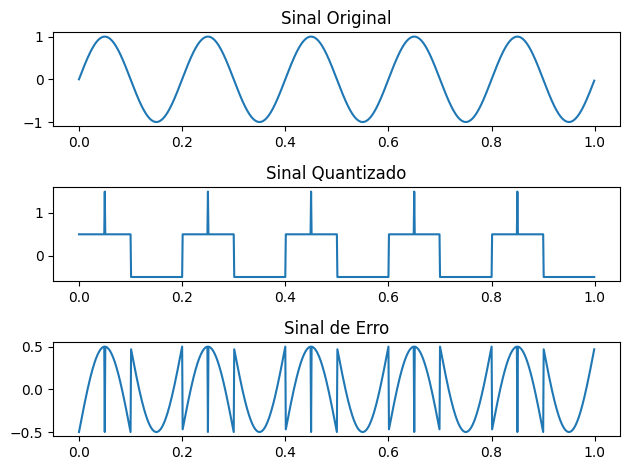

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def quantificadorIntegrado2(x, Vmax, R):
    '''
    Quantificador Uniforme MidRise

    Parâmetros:
    - x: sinal de entrada a quantificar
    - Vmax: valor maximo da gama dinamica (assumindo [-Vmax, Vmax])
    - R: numero de bits do quantificador
    
    Retorna:
    - xq: sinal quantificado
    - iq: indices do sinal quantificado
    '''
    Vmin = -Vmax
    delta = (Vmax-Vmin)/2**R
    nQuantificacao= np.arange(Vmin+delta/2,Vmax,delta)
    fronteiras = np.arange(Vmin+delta,Vmax+delta/2,delta)
    indices=np.arange(len(nQuantificacao))
    xqq=np.zeros(len(x))
    iq=np.zeros(len(x))
    for i in range(len(x)):
        t = x[i] < fronteiras
        j = indices[t][0]
        iq[i] = j
        xqq[i]= nQuantificacao[j]
    return xqq, iq

def sinal_erro(sinal, sinalQuantificado):
    sinalErro = sinal - sinalQuantificado
    return sinalErro


# Parâmetros da função sinusoidal
frequencia = 5  # Frequência em Hz
amplitude = 1  # Amplitude da onda
duracao = 1   # Duração do sinal em segundos
sampling_rate = 1000  # Taxa de amostragem em Hz
t = np.arange(0, duracao, 1/sampling_rate)

sinal = amplitude * np.sin(2 * np.pi * frequencia * t)

Vmax = 4
nbits = 3

sinalQuantificado, _ = quantificadorIntegrado2(sinal, Vmax, nbits)

sinalErro = sinal_erro(sinal, sinalQuantificado)


plt.subplot(3, 1, 1)
plt.plot(t, sinal, label='Sinal Original')
plt.title('Sinal Original')

plt.subplot(3, 1, 2)
plt.plot(t, sinalQuantificado, label='Sinal Quantizado')
plt.title('Sinal Quantizado')

plt.subplot(3, 1, 3)
plt.plot(t, sinalErro, label='Sinal de Erro')
plt.title('Sinal de Erro')

plt.tight_layout()


Represente o histograma do sinal de erro. Comente os resultados.

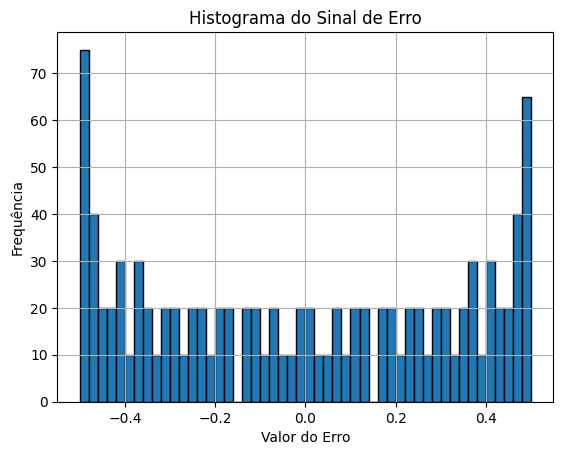

In [2]:
# Plotar histograma do sinal de erro
plt.figure()
plt.hist(sinalErro, bins=50, edgecolor="black")
plt.title('Histograma do Sinal de Erro')
plt.xlabel('Valor do Erro')
plt.ylabel('Frequência')
plt.grid(True)

## A.2 Relação de Sinal Ruído 

Crie uma função que meça o SNR prático, ou seja, medindo a potência do sinal e a potência do sinal de erro (neste caso de quantificação).

In [3]:
def Measure_SNRp(sinal, sinalQuantificado):
    """
    Calcula o SNR prático.

    Parâmetros:
    - sinal: Sinal Original.
    - sinalQuantificado: Sinal Quantificado.

    Retorna:
    - SNR em decibéis.
    """

    # Calcule a potência do sinal original
    sinal_potencia = np.sum(np.abs(sinal)**2) / len(sinal)

    # Calcule a potência do sinal de erro (sinal quantizado)
    sinalErro = sinal - sinalQuantificado
    sinalErro_potencia = np.sum(np.abs(sinalErro)**2) / len(sinalErro)

    # Calcule o SNR prática em dB
    SNRp = 10 * np.log10(sinal_potencia / sinalErro_potencia)

    return SNRp

Crie uma função que calcule o SNR para o caso da quantificação uniforme.

$SNRt_{dB}= 6,02 \times N_b + 10 \log_{10} \frac{3 P_x}{V_{max}}$

In [4]:
def SNR_quantificacao_uniforme(Nb, Px, Vmax):
    """
    Calcula a SNR para o caso de quantificação uniforme.

    Parâmetros:
    - Nb: Número de bits usados para quantificação.
    - Px: Potência do sinal.
    - Vmax: Amplitude máxima do sinal.

    Retorna:
    - SNR em decibéis.
    """
    
    # Calcula a SNR total em decibéis
    SNR_dB = 6.02 * Nb + 10 * np.log10(3 * Px / Vmax)

    return SNR_dB


## A.3 Testes
Considere um sinal de rampa, x(t), entre [-Vmax, Vmax] com um incremento defenido por si.
Realize a quantificação deste sinal para cada valor de R={3,4,5,6,7,8}.
Meça a SNR prática e o valor teórico. 
Construa um gráfico com ambos os valores da SNR teórica e medida em função do número de bits R. Comente os resultados.

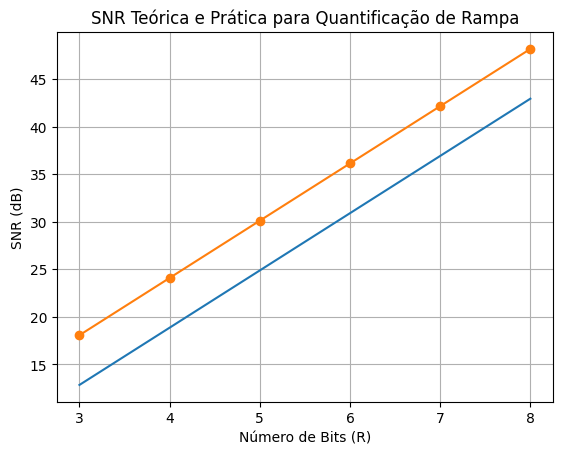

In [5]:
R_values = [3, 4, 5, 6, 7, 8]
Vmax = 5
increment = 0.01


def sinalRampa_quantificado(sinalRampa, R):
    """
    Quantificação do sinal de rampa

    Parâmetros:
    - SinalRampa: Sinal de rampa
    - R: Número de Bits

    Retorna:
    - Sinal de rampa quantificado.
    """

    # Quantização uniforme
    sinalRampa_Quantificado = np.round(sinalRampa * (2 ** (R - 1)) / Vmax) * Vmax / (2 ** (R - 1))

    return sinalRampa_Quantificado

sinalRampa = np.arange(-Vmax, Vmax, increment)
sinal_potencia = np.sum(np.abs(sinal)**2) / len(sinal)

# Inicialize listas para armazenar os resultados
snr_quantificacao_uniforme_valores = []
snr_pratico_valores = []

# Calcule SNR teórica e prática para cada valor de R
for R in R_values:
    sinalRampa_Quantificado = sinalRampa_quantificado(sinalRampa, R)
    snr_quantificacao_uniforme = SNR_quantificacao_uniforme(R, sinal_potencia, Vmax)
    snr_pratico = Measure_SNRp(sinalRampa, sinalRampa_Quantificado)

    snr_quantificacao_uniforme_valores.append(snr_quantificacao_uniforme)
    snr_pratico_valores.append(snr_pratico)

# Construa o gráfico
plt.plot(R_values, snr_quantificacao_uniforme_valores, label='SNR Quantificação Uniforme')
plt.plot(R_values, snr_pratico_valores, label='SNR Prática', marker='o')
plt.xlabel('Número de Bits (R)')
plt.ylabel('SNR (dB)')
plt.title('SNR Teórica e Prática para Quantificação de Rampa')
plt.grid(True)


## A.4 Testes com voz
Grave um sinal de voz através do microfone com aproximadamente um segundo de duração. Faça a quantifição do sinal para cada valor de R={3,4,5,6,7,8}. Meça a SNR prática e o valor teórico (para determinar a potência no caso teórico deve usar o mesmo valor que na prática). Construa um gráfico com ambos os valores da SNR teórica e SNR medida em função do número de bits R. Comente os resultados

In [6]:
import scipy.io.wavfile as wav
"""
fs, data = wav.read(".wav")
plt.plot(data)
data
"""

'\nfs, data = wav.read(".wav")\nplt.plot(data)\ndata\n'

# B. Codificação/ Descodificação

Construa uma função Python que dado um Numpy array (com dimensão  𝑁 ) com valores inteiros, retorne um Numpy array (com dimensão  𝑁.𝑅×1 ) com os mesmos valores convertidos para binário. Para facilitar a realização do processamento nos blocos subsequentes aconselha-se a que cada bit esteja guardado individualmente. Esta função ainda deve receber como parâmetros de entrada o número de bits ( 𝑅 ) a usar na conversão de cada inteiro.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def Codific(arr_signal_quantized, R):
    # Função para converter um número inteiro para binário e ajustar o comprimento dos bits
    def int_to_binary(value, num_bits):
        binary_str = np.binary_repr(value, width=num_bits)
        return np.array(list(map(int, binary_str)))

    # Aplica a função para cada elemento no array original
    arr_binary = np.apply_along_axis(int_to_binary, axis=0, arr=arr_signal_quantized, num_bits=R)

    # Retorna o array resultante
    return arr_binary

Construa uma função que dado um Numpy array com valores dos bits, faça a conversão para inteiros (considerando R bits).

In [8]:
def Descodific(arr_binary, R):
    # Função para converter uma sequência de bits para inteiro
    def binary_to_int(bits):
        return np.packbits(bits, bitorder='big')[0]

    # Aplica a função para cada coluna no array binário
    arr_signal = np.apply_along_axis(binary_to_int, axis=0, arr=arr_binary[:, :R])

    # Retorna o array resultante
    return arr_signal

Com base nas funções já implementadas, faça a codificação e descodificação PCM uniforme do sinal de áudio previamente gravado. Verifique qual a SNR obtida e ouça o sinal descodificado. Use para o efeito R=3, 5 e 8.

In [9]:
#Resposta:

# C.  Deteção e Correção de erros 

Construa uma função que implemente o Hamming(7,4). Utilize a seguinte matriz geradora: